# Prepare data

download data from https://forexsb.com/historical-forex-data

## read dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('USDCAD_H4.csv', sep='\t')
df.columns = [c.lower() for c in df.columns]
df.head()

,time,open,high,low,close,volume
0,2008-02-14 16:00:00,0.99800,0.99985,0.99720,0.99980,8162
1,2008-02-14 20:00:00,0.99980,1.00070,0.99830,1.00015,12631
2,2008-02-15 00:00:00,1.00015,1.00020,0.99905,0.99950,4417
3,2008-02-15 04:00:00,0.99950,0.99990,0.99705,0.99720,5803
4,2008-02-15 08:00:00,0.99720,0.99890,0.99195,0.99585,12635


## data visualization

In [2]:
import plotly.graph_objects as go

start, end = -200, None
fig = go.Figure(data=[
    go.Candlestick(
      x=df.iloc[start:end]['time'],
      open=df.iloc[start:end]['open'],
      high=df.iloc[start:end]['high'],
      low=df.iloc[start:end]['low'],
      close=df.iloc[start:end]['close']
    )
])

fig.show()

# Methodologies

This method quantizes the signal and creates a vocabulary to be used as tokens of the language of the signal. Then LLM architecture will be trained for the next token prediction.

## Preprocess

In [2]:
data = df.iloc[:, 1:].to_numpy()  # ignore 'time' column and convert to numpy
data = data[::-1]  # newset candle should be at index 0

data.shape

(25847, 5)

In [11]:
q = 5  # quantization length
sq = 2  # shadow length

def candles_to_vector(candles):
  base = candles[0][0]  # open value of the first candle considered as base for all values
  vec = candles.reshape(-1) - base  # flatten data and subtract base from all
  vec[0] = base
  return vec

def vector_to_candles(vec):
  base = vec[0]
  candles = vec.reshape((-1, 5)) + base
  candles[0][0] = base
  return candles

def quantize(candles, q, sq):
  n, m = candles.shape
  Q = []
  for i in range(sq, n, q):
    if i+q+sq >= n: break
    vec = candles_to_vector(candles[i-sq:i+q+sq])
    Q.append(vec)
  return np.array(Q)


Q = quantize(data, q, sq)
Q.shape

(5168, 45)

### Dimentionality reduction

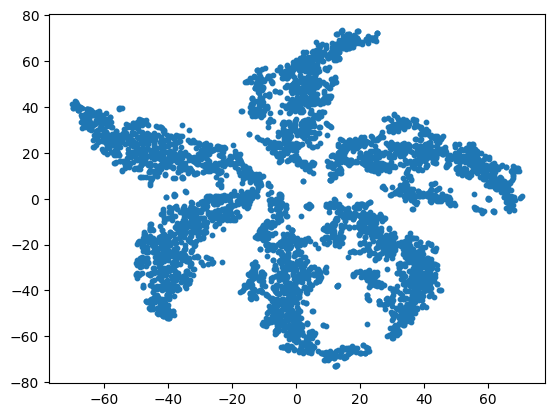

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2,
            perplexity=30,
            learning_rate='auto',
            init='pca',
            random_state = 0)

Q_2d = tsne.fit_transform(Q)

plt.scatter(Q_2d[:, 0], Q_2d[:, 1], s=10)
plt.show()

### Clustring

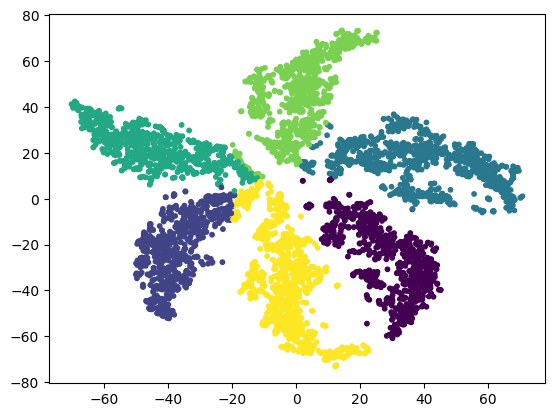

In [14]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=6,
                      max_iter=1000,
                      random_state=0)
labels = gmm.fit_predict(Q_2d)

plt.scatter(Q_2d[:, 0], Q_2d[:, 1], s=10, c=labels)
plt.show()

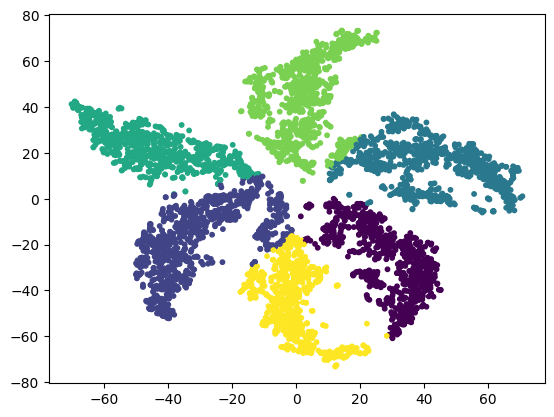

In [38]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0, n_init="auto", max_iter=1000)
kmeans.fit(Q_2d)

plt.scatter(Q_2d[:, 0], Q_2d[:, 1], s=10, c=kmeans.labels_)
plt.show()

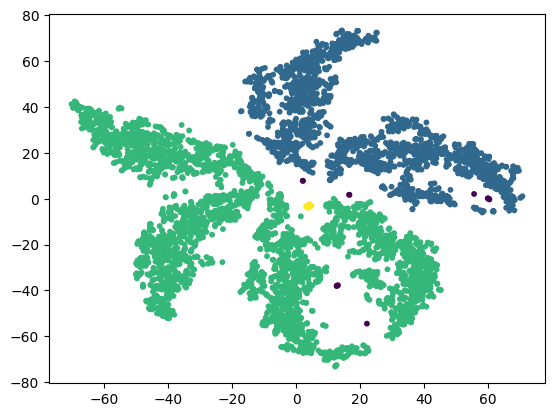

In [9]:
from sklearn.cluster import DBSCAN

dbs = DBSCAN(eps=4.5, min_samples=6)
dbs.fit(Q_2d)

plt.scatter(Q_2d[:, 0], Q_2d[:, 1], s=10, c=dbs.labels_)
plt.show()

### Generate samples according to clustring

In [28]:
w = 5  # window size (number of tokens in a sample)

def generage_samples(Q, lables, w):
  n, m = Q.shape
  X, y = [], []
  i = 0
  while i + w + 1 < n:
    X.append(labels[i : i+w])
    y.append(labels[i+w])
    i += (w+1)
  return pd.DataFrame({'X':X, 'y':y})

samples = generage_samples(Q, labels, w)
samples

,X,y
0,"[2, 4, 3, 1, 5]",2
1,"[4, 3, 1, 5, 0]",2
2,"[3, 1, 5, 0, 2]",4
3,"[1, 5, 0, 2, 4]",3
4,"[5, 0, 2, 4, 3]",1
...,...,...
856,"[5, 5, 5, 0, 2]",5
857,"[5, 5, 0, 2, 2]",4
858,"[3, 5, 0, 4, 3]",0
859,"[1, 0, 0, 5, 3]",0


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(samples.X, samples.y, test_size=0.2, random_state=42)
train_data = pd.concat((X_train, y_train), axis=1)
X_train, X_val, y_train, y_val = train_test_split(train_data.X, train_data.y, test_size=0.1, random_state=42)

print(f'X_train:{X_train.shape}  y_train:{y_train.shape}')
print(f'X_test :{X_test.shape}  y_test :{y_test.shape}')
print(f'X_val  :{X_val.shape}   y_val  :{y_val.shape}')

X_train:(619,)  y_train:(619,)
X_test :(173,)  y_test :(173,)
X_val  :(69,)   y_val  :(69,)


## Train GPT

In [33]:
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [34]:
class ChartDataset(Dataset):
    def __init__(self, x, y):
      self.x = x
      self.y = y

    def __getitem__(self, idx):
      input = {'input_ids': torch.tensor(self.x[idx]).to(device), 'attention_mask': torch.ones(len(self.x[idx])).to(device)}
      labels = torch.ones(len(self.x[idx]), dtype=torch.long) * -100
      labels[-1] = self.y[idx]
      # labels[-3:-1] = torch.tensor(self.x[idx][-2:])
      labels = labels.to(device)
      return input, labels

    def __len__(self):
      return len(self.y)

train_dataset = ChartDataset(X_train.to_numpy(), y_train.to_numpy())
val_dataset = ChartDataset(X_val.to_numpy(), y_val.to_numpy())
test_dataset = ChartDataset(X_test.to_numpy(), y_test.to_numpy())

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [43]:
def train_one_epoch(model, dataloader, optimizer):
  model.train()
  accu_loss = 0
  for x, y in dataloader:
    optimizer.zero_grad()
    loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
    accu_loss += loss.item()
    loss.backward()
    optimizer.step()
  overall_loss = accu_loss / len(dataloader)
  return overall_loss

def test_one_epoch(model, dataloader):
  model.eval()
  with torch.no_grad():
    accu_loss = 0
    for x, y in dataloader:
      loss = model(input_ids=x['input_ids'], attention_mask=x['attention_mask'], labels=y).loss
      accu_loss += loss.item()
    overall_loss = accu_loss / len(dataloader)
  return overall_loss

In [38]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, GPT2Config

configuration = GPT2Config(vocab_size=6, n_positions=w+1)
gpt_pretrained = GPT2LMHeadModel.from_pretrained('gpt2')
gpt = GPT2LMHeadModel(configuration)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [39]:
state = gpt_pretrained.state_dict()
del state['transformer.wte.weight']
del state['transformer.wpe.weight']
del state['lm_head.weight']
gpt.load_state_dict(state, strict=False)

_IncompatibleKeys(missing_keys=['transformer.wte.weight', 'transformer.wpe.weight', 'lm_head.weight'], unexpected_keys=[])

In [40]:
for i, j in zip(gpt.parameters(), gpt_pretrained.parameters()):
  if i.shape != j.shape:
    continue
  i.requires_grad = False

In [41]:
lr = 1e-4
optimizer = Adam(gpt.parameters(), lr=lr)
gpt = gpt.to(device)
epoch = 30

In [44]:
import gc
train_losses = []
val_losses = []
for i in range(epoch):
  gc.collect()
  train_loss = train_one_epoch(gpt, train_dataloader, optimizer)
  val_loss = test_one_epoch(gpt, val_dataloader)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f'Epoch {i+1}: Train Loss = {train_loss:0.3}, Val Loss = {val_loss:0.3}')

Epoch 1: Train Loss = 4.56, Val Loss = 3.51
Epoch 2: Train Loss = 3.86, Val Loss = 2.99
Epoch 3: Train Loss = 3.11, Val Loss = 2.37
Epoch 4: Train Loss = 2.66, Val Loss = 1.82
Epoch 5: Train Loss = 2.44, Val Loss = 1.76
Epoch 6: Train Loss = 2.27, Val Loss = 1.72
Epoch 7: Train Loss = 2.1, Val Loss = 1.54
Epoch 8: Train Loss = 2.08, Val Loss = 1.48
Epoch 9: Train Loss = 2.04, Val Loss = 1.49
Epoch 10: Train Loss = 1.91, Val Loss = 1.48
Epoch 11: Train Loss = 1.88, Val Loss = 1.43
Epoch 12: Train Loss = 1.85, Val Loss = 1.45
Epoch 13: Train Loss = 1.89, Val Loss = 1.49
Epoch 14: Train Loss = 1.82, Val Loss = 1.48
Epoch 15: Train Loss = 1.81, Val Loss = 1.46
Epoch 16: Train Loss = 1.8, Val Loss = 1.55
Epoch 17: Train Loss = 1.83, Val Loss = 1.49
Epoch 18: Train Loss = 1.74, Val Loss = 1.6
Epoch 19: Train Loss = 1.78, Val Loss = 1.51
Epoch 20: Train Loss = 1.7, Val Loss = 1.39
Epoch 21: Train Loss = 1.75, Val Loss = 1.3
Epoch 22: Train Loss = 1.7, Val Loss = 1.37
Epoch 23: Train Loss = 1.

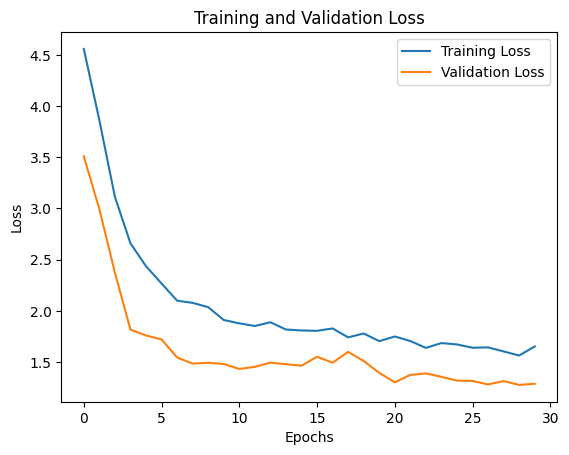

In [45]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(loc='best')
plt.show()